 
# <font color='#F5B167'> MD009 Ejemplos de los distintos métodos </font>

### <font color='#F5B167'> MD009 EJEMPLO MÉTODO DE LA COMPOSICIÓN </font>

Veamos cómo el método de la composición funciona generando la función ejemplo vista en clase, $f(x)=\frac{5}{12}(1+(x-1)^4)$.
Este método consiste en escribir la función a partir de otras dos de las que sepamos generar números aleatorios. Por ejemplo, $f(x)=\frac{5}{6}p(x)+\frac{1}{6}q(x)$, donde $p(x)=\frac{1}{2}$ y $q(x)=\frac{5}{2}(x-1)^4$.
A partir de dos números aleatorios uniformes y utilizando el método de la transformación inversa para $p(x)$ y $q(x)$, podemos generar la distribución de $f(x)$.

In [1]:
x <- 0
for(k in 1:10000){
    u1 = runif(1, 0, 1) #generamos un número aleatorio entre el 0 y el 1
    u2 = runif(1, 0, 1) 
    if(u1 < 5/6){    #si el primer número generado es menor a 5/6, el valor de x será 2 veces el valor del segundo número
        x[k] <- 2*u2
    }else{
        if(2*u2-1 > 0){      #sino, el valor de x será uno más la raíz quinta de 2 veces el segundo menos uno       
          x[k] <- (2*u2-1)^(1/5) + 1
        }
        else{
            x[k] <- -(1-2*u2)^(1/5) + 1
        }
    }
}

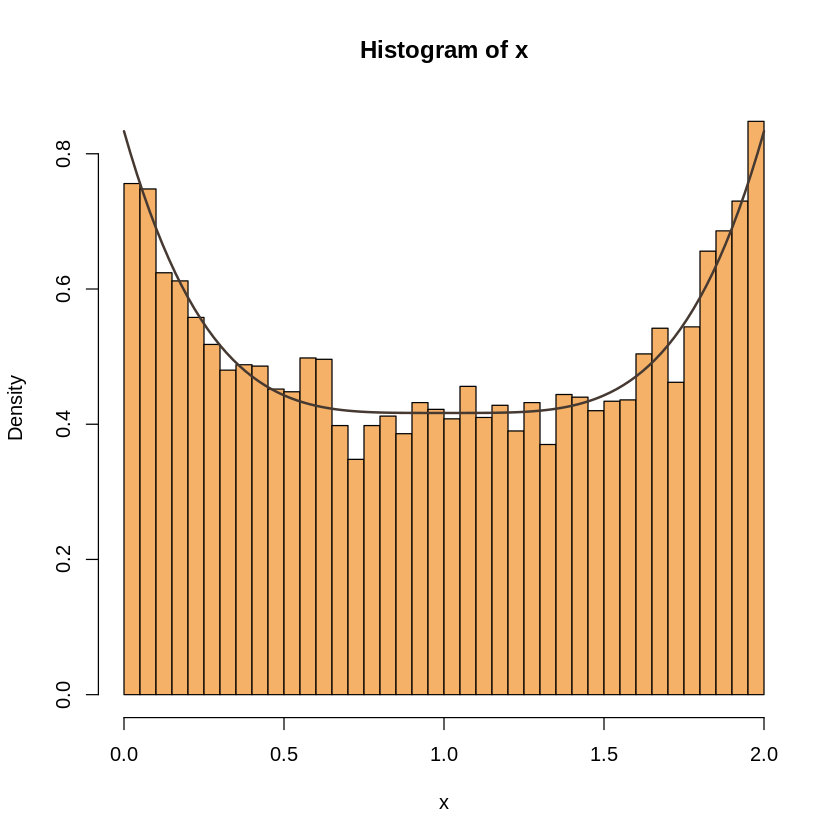

In [3]:
hist(x, freq = FALSE, breaks = 50, col = '#F5B167')
curve((5/12)*(1+(x-1)^4), from = 0, to = 2, col = '#463932', add = TRUE, lw = 2)

### <font color='#F5B167'> MD009 EJEMPLO MÉTODO DE ACEPTACIÓN-RECHAZO</font>

Queremos generar mediante el método de aceptación/rechazo una variable aleatoria que se distribuye según la función densidad de probabilidad siguiente:

$f(x)=\frac{2}{\pi}\sqrt{1-x^2}$ con $x\in[-1, 1]$.

El primer paso es generar valores de x entre -1 y 1. Después generamos otro número aleatorio, y, entre 0 y un valor mayor o igual al máximo de la función, en este caso $\frac{2}{\pi}$. Si $y\leq f(x)$, aceptamos ese valor de x (como una variable x_accepted).

In [4]:
x_accepted <- 0
nx = 1
count = 0
while(nx <= 10000){
    count = count + 1
    x <- runif(1, -1, 1) #generamos un número aleatorio entre el -1 y el 1
    y <- runif(1, 0, 2/pi) #generamos un número aleatorio entre 0 y 2*pi
    fx = 2*sqrt(1-x^2)/pi #aplicamos el primer número generado a la función
    if (y <= fx){ #si el segundo valor generado es menor o igual al valor de la función, guardamos el valor de x
        x_accepted[nx] = x
        nx = nx + 1
    } 
}

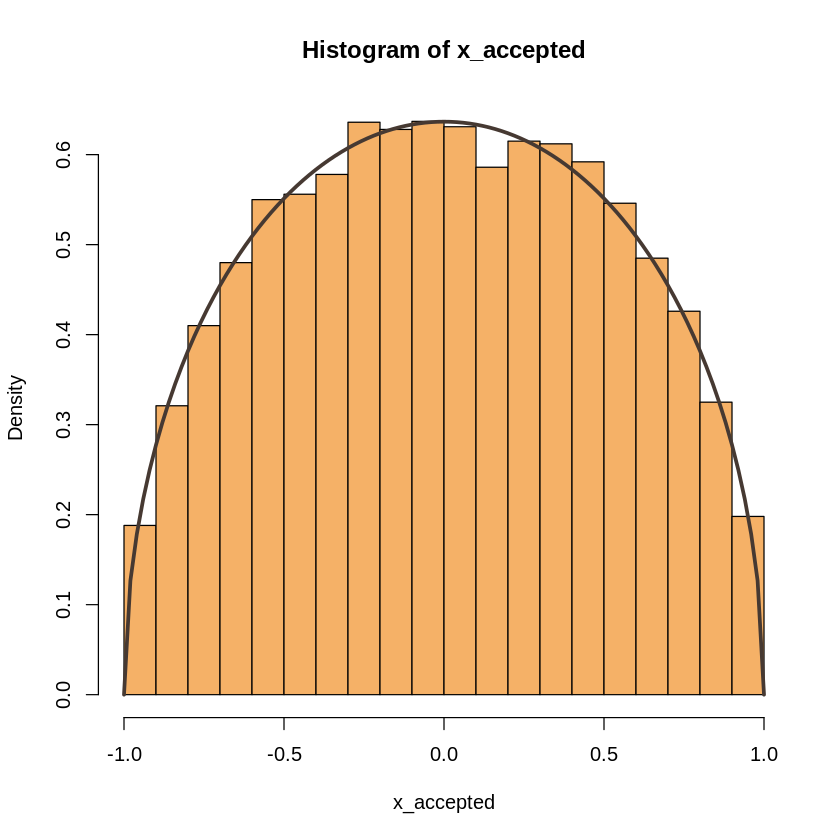

In [5]:
hist(x_accepted, freq = F, col = '#F5B167')
curve(2*sqrt(1-x^2)/pi, from = -1, to = 1, col = '#463932', add = T, lwd = 3)

¿Cuál es la eficiencia en la generación? 

La eficiencia en la generación sería el cociente del número de valores aceptados (10000) respecto al total generados:

In [7]:
eff <- length(x_accepted)/count
eff

[1] 0.7913271

Obtenemos un 79% de eficiencia en la generación. Podemos comprobar si coindice con la eficiencia esperada, que corresponde al cociente entre el área de f(x), que es uno, y el del rectángulo de lados 2 y $2/\pi$, que es $4/\pi$. Así la eficiencia teórica sería $\pi/4=0.785$, que coincide aproximadamente con el valor obtenido.